In [1]:
# Setup & Imports
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Consistent styling across all charts
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        150,
})

# Color palette 
COLOR_ATTRITION = {'Yes': '#113366', 'No': '#080813'}
COLOR_PRIMARY   = '#2B888D'   
COLOR_ACCENT    = '#113366'  
COLOR_LIGHT     = '#BCB6CB'  
COLOR_NEUTRAL   = '#E8DAD6'   

In [2]:
# Load dataset
df = pd.read_csv('/Users/thaole/pgdata/hr_attrition.csv')

# Quick check
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 1470
Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Data Quality Check
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove columns where every value is the same -- not useful for analysis
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Convert Attrition from Yes/No to 1/0 for calculations
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

Shape: (1470, 35)
Missing values: 0
Duplicate rows: 0


In [4]:
# Overall attrition rate
overall_rate = df['Attrition_Binary'].mean() * 100
print(f"Overall attrition rate: {overall_rate:.1f}%")

Overall attrition rate: 16.1%


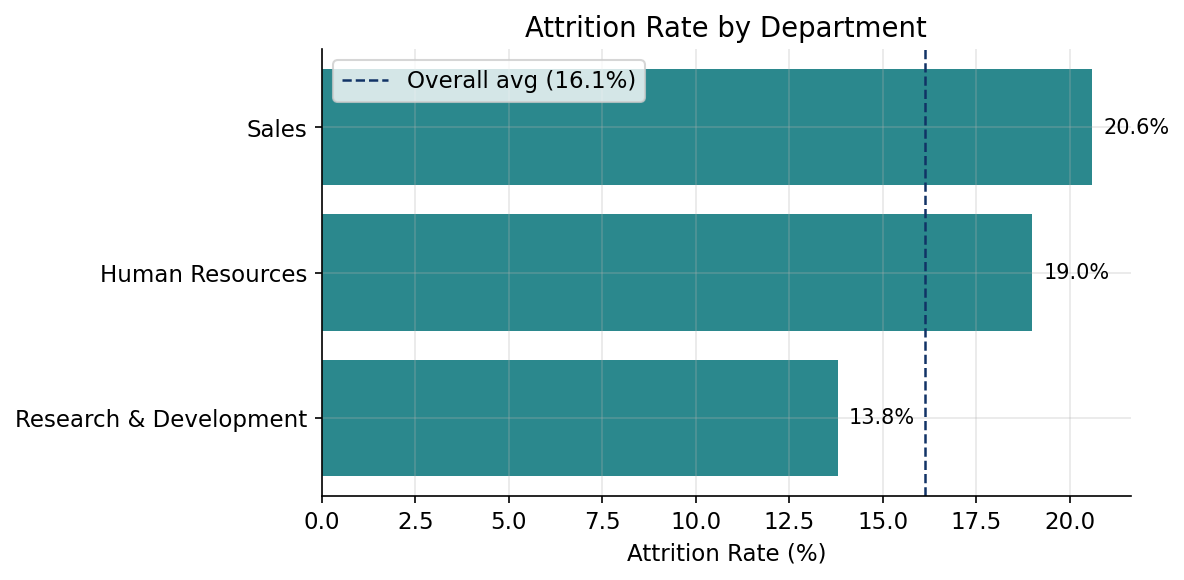

In [5]:
# Attrition rate by department
dept_attrition = (
    df.groupby('Department')['Attrition_Binary']
    .mean() * 100
).round(1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(dept_attrition.index, dept_attrition.values, color=COLOR_PRIMARY)
ax.axvline(overall_rate, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department')
ax.legend()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{w}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/dept_attrition.png', bbox_inches='tight')
plt.show()

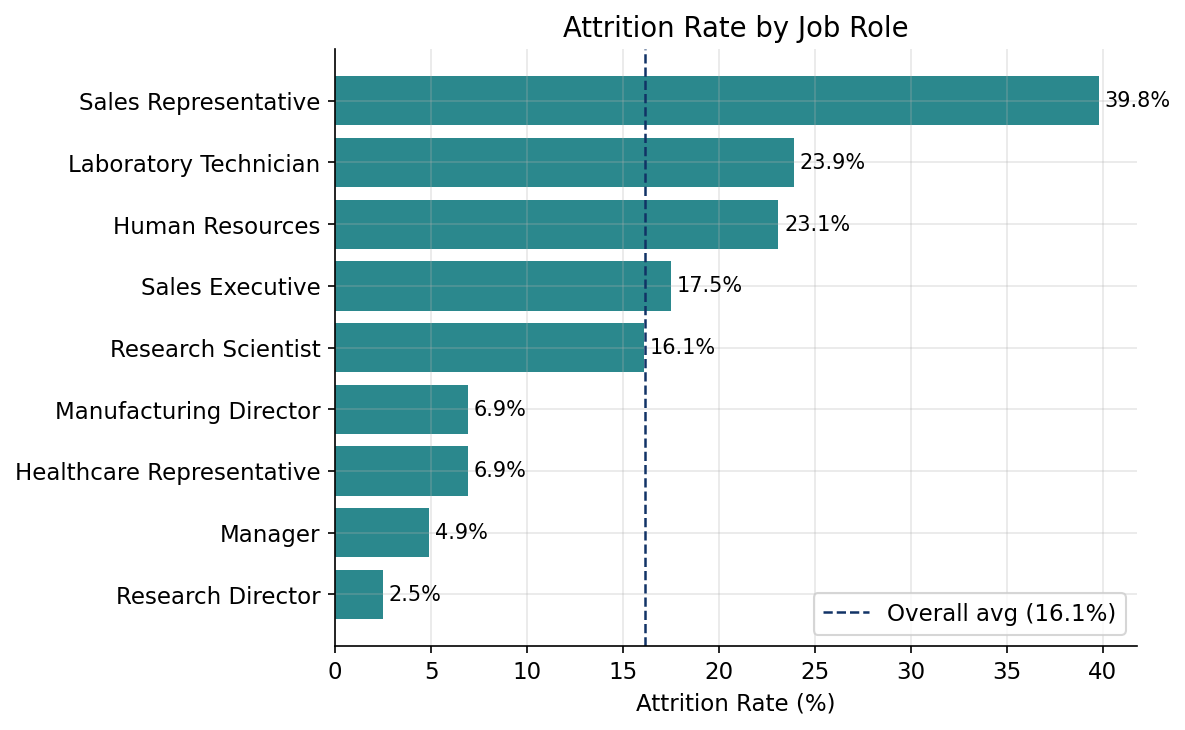

In [6]:
# Attrition rate by job role
role_attrition = (
    df.groupby('JobRole')['Attrition_Binary']
    .mean() * 100
).round(1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(role_attrition.index, role_attrition.values, color=COLOR_PRIMARY)
ax.axvline(overall_rate, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role')
ax.legend()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{w}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/role_attrition.png', bbox_inches='tight')
plt.show()

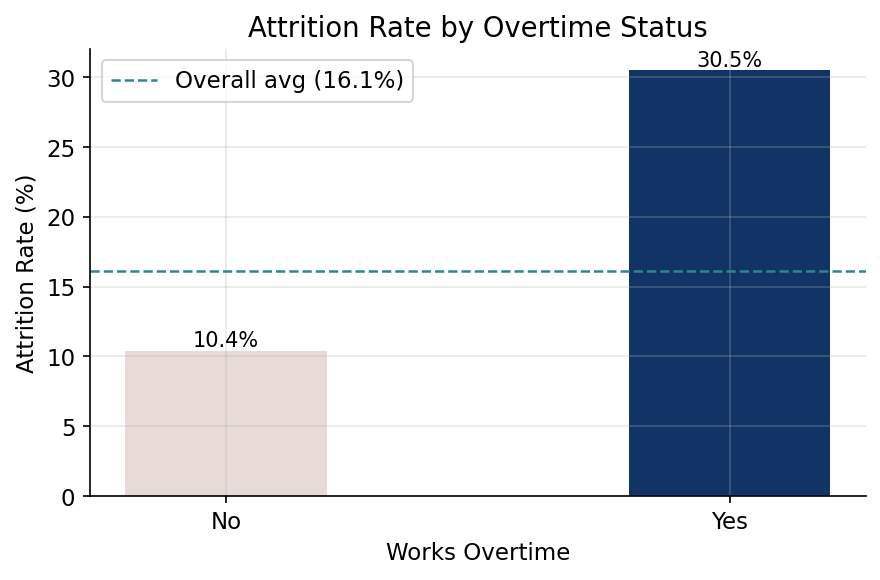

In [7]:
# Attrition rate by overtime
overtime_attrition = (
    df.groupby('OverTime')['Attrition_Binary']
    .mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(overtime_attrition.index, overtime_attrition.values, 
              color=[COLOR_NEUTRAL, COLOR_ACCENT], width=0.4)
ax.axhline(overall_rate, color=COLOR_PRIMARY, linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Works Overtime')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Overtime Status')
ax.legend()

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
            f'{h}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/overtime_attrition.png', bbox_inches='tight')
plt.show()

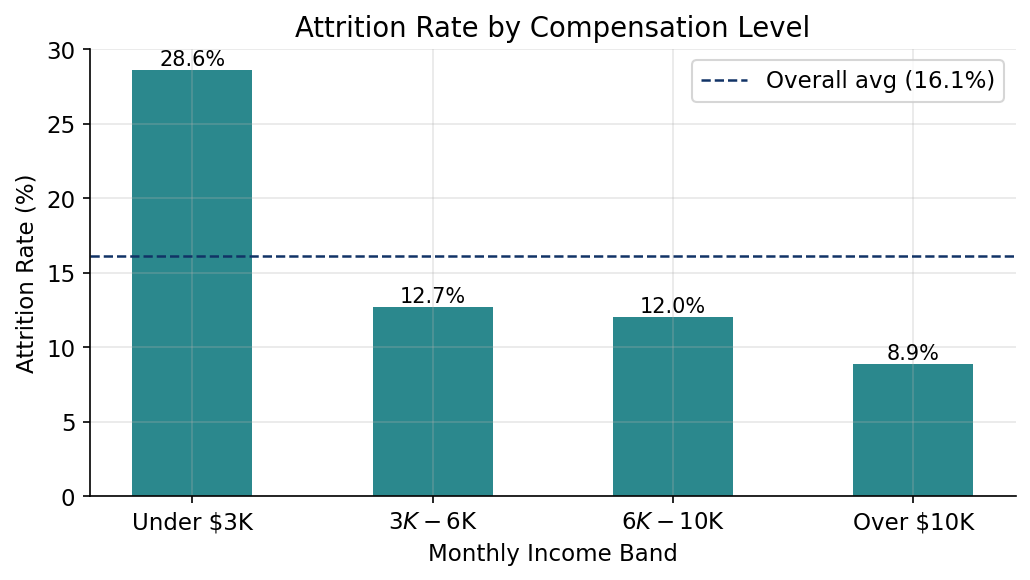

In [8]:
# Attrition rate by income band
df['income_band'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, float('inf')],
    labels=['Under $3K', '$3K-$6K', '$6K-$10K', 'Over $10K']
)

income_attrition = (
    df.groupby('income_band', observed=True)['Attrition_Binary']
    .mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(income_attrition.index, income_attrition.values, color=COLOR_PRIMARY, width=0.5)
ax.axhline(overall_rate, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Monthly Income Band')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Compensation Level')
ax.legend()

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
            f'{h}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/income_attrition.png', bbox_inches='tight')
plt.show()

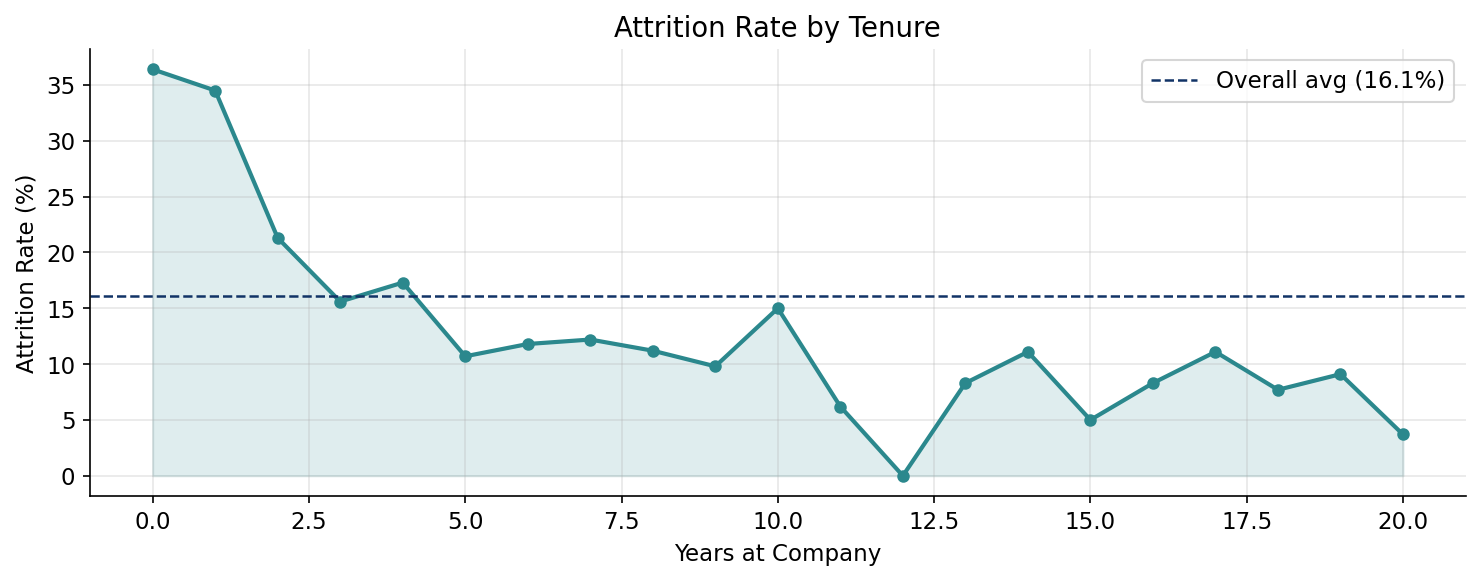

In [9]:
# Attrition rate by years at company
tenure_attrition = (
    df.groupby('YearsAtCompany')['Attrition_Binary']
    .mean() * 100
).round(1)

# Cap at 20 years so the chart stays readable
tenure_attrition = tenure_attrition[tenure_attrition.index <= 20]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tenure_attrition.index, tenure_attrition.values, 
        color=COLOR_PRIMARY, linewidth=2, marker='o', markersize=5)
ax.fill_between(tenure_attrition.index, tenure_attrition.values, 
                alpha=0.15, color=COLOR_PRIMARY)
ax.axhline(overall_rate, color=COLOR_ACCENT, linestyle='--', 
           linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Tenure')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/tenure_attrition.png', bbox_inches='tight')
plt.show()

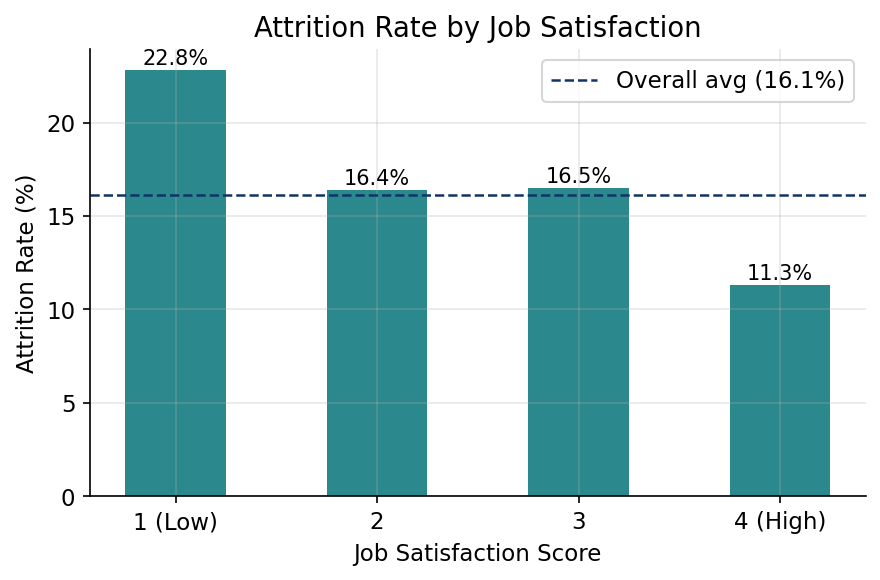

In [10]:
# Attrition rate by job satisfaction score
satisfaction_attrition = (
    df.groupby('JobSatisfaction')['Attrition_Binary']
    .mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['1 (Low)', '2', '3', '4 (High)'],
    satisfaction_attrition.values,
    color=COLOR_PRIMARY,
    width=0.5
)
ax.axhline(overall_rate, color=COLOR_ACCENT, linestyle='--',
           linewidth=1.2, label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('Job Satisfaction Score')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Satisfaction')
ax.legend()

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
            f'{h}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/thaole/pgdata/visuals/satisfaction_attrition.png', bbox_inches='tight')
plt.show()